# Support Vector Machine

A Support Vector Machine (SVM) is a supervised learning algorithm used to predict categorical data.  The idea is to map the data to a "feature space" in which we use the feature variables to create a high-dimensional representation of the data.  In this feature space we attempt to find ways to separate the data into classes that might not be apparent in other machine learning algorithms for classification problems that rely on linear separators to make classification decisions.

Here, we will build and train an SVM model to predict whether cells in a publicly available dataset are malignant or benign.

## The Data Set

The dataset we are using for this example is a publicly available dataset on cancer cells from the UCI Machine Learning Repository (http://mlearn.ics.uci.edu/MLRepository.html).  There are several hundred records which contain the following fields:

| Field Name | Description |
------- | ----- |
| ID | Identification Number |
| Clump | Clump thickness |
| UnifSize | Uniformity of the cell size |
| UnifShape | Uniformity of the cell shape |
| MargAdh | Marginal adhesion |
| SingEpiSize | Single epithelial cell size |
| BareNuc | Bare nuclei |
| BlandChrom | Bland chromatin |
| NormNucl | Normal Nucleoli |
| Mit | Mitoses |
| Class | Benign or malignant |

First we import necessary libraries and load the data into a pandas dataframe.

In [1]:
import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
cell_df = pd.read_csv("cell_samples.csv")
cell_df.head()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


The ID field is a patient identifier.  The other characteristic fields (Clump through Mit) contain values that range from 1 to 10.  Finally the Class field contains either 2 (benign) or 4 (malignant).

Let's look at some characteristics of the data in a plot.

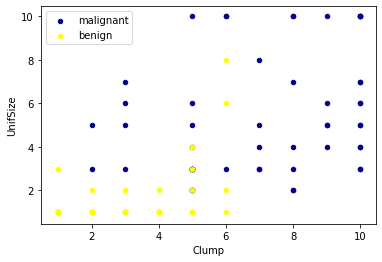

In [3]:
ax = cell_df[cell_df['Class'] == 4][0:50].plot(kind='scatter', x='Clump', y='UnifSize', color='DarkBlue', label='malignant');
cell_df[cell_df['Class'] == 2][0:50].plot(kind='scatter', x='Clump', y='UnifSize', color='Yellow', label='benign', ax = ax);
plt.show()

## Data Preprocessing and Data Selection

Here we take a look at some of the data and apply a few transformations to clean things up and get them into a format for use in building the SVM.

In [4]:
# Display the datatypes of the columns

cell_df.dtypes

ID              int64
Clump           int64
UnifSize        int64
UnifShape       int64
MargAdh         int64
SingEpiSize     int64
BareNuc        object
BlandChrom      int64
NormNucl        int64
Mit             int64
Class           int64
dtype: object

In [5]:
# Drop the non-numerical values from the BareNuc column

cell_df = cell_df[pd.to_numeric(cell_df['BareNuc'], errors = 'coerce').notnull()]
cell_df['BareNuc'] = cell_df['BareNuc'].astype('int')

# Double check

cell_df.dtypes

ID             int64
Clump          int64
UnifSize       int64
UnifShape      int64
MargAdh        int64
SingEpiSize    int64
BareNuc        int64
BlandChrom     int64
NormNucl       int64
Mit            int64
Class          int64
dtype: object

In [6]:
# Create a dataframe with the features we want to use.

feature_df = cell_df[['Clump', 'UnifSize', 'UnifShape', 'MargAdh', 'SingEpiSize', 'BareNuc', 'BlandChrom', 'NormNucl', 'Mit']]
X = np.asarray(feature_df)
X[0:5]

array([[ 5,  1,  1,  1,  2,  1,  3,  1,  1],
       [ 5,  4,  4,  5,  7, 10,  3,  2,  1],
       [ 3,  1,  1,  1,  2,  2,  3,  1,  1],
       [ 6,  8,  8,  1,  3,  4,  3,  7,  1],
       [ 4,  1,  1,  3,  2,  1,  3,  1,  1]])

In [7]:
# Load the class of the cells into a dataframe.  These are the values we want to predict.

cell_df['Class'] = cell_df['Class'].astype('int')
y = np.asarray(cell_df['Class'])
y [0:5]

array([2, 2, 2, 2, 2])

## Train/Test Split

We split the data into training and testing sets using scikit-learning preprocessing functions.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 4)
print("Train set: ", X_train.shape, y_train.shape)
print("Test set: ", X_test.shape, y_test.shape)

Train set:  (546, 9) (546,)
Test set:  (137, 9) (137,)


## Modeling 

The process of mapping the data into a higher-dimensional space is called kernelling and there are several different functions we can choose in the SVM algorithm to perform this mapping.  Some examples are linear, polynomial, Radial Basis Function (RBF) and sigmoid.

There are various pros and cons to each function which are beyond the scope of our example here.  Typically we would just try out some options and see what works for our particular dataset.

In this case we'll use an RBF for kernelling.

In [9]:
# Here we create the model and train it on the training set.

from sklearn import svm
clf = svm.SVC(kernel = 'rbf')
clf.fit(X_train, y_train)

SVC(C=1.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)

In [10]:
# Use the model to predict values

yhat = clf.predict(X_test)
yhat[0:5]

array([2, 4, 2, 4, 2])

## Evaluation

We use some standard evaluation metrics and visualization tools to look at the performance of the model.

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools

In [12]:
def plot_confusion_matrix(cm, classes, normalize = False, title = 'Confusion matrix', cmap = plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis]
        print ("Normalized confusion matrix")
    else:
        print ("Confusion matrix, without normalization")
    
    print(cm)
    
    plt.imshow(cm, interpolation = 'nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation = 45)
    plt.yticks(tick_marks, classes)
    
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i,j], fmt),
                horizontalalignment = "center",
                color = "white" if cm[i,j] > thresh else "black")
    
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

              precision    recall  f1-score   support

           2       1.00      0.94      0.97        90
           4       0.90      1.00      0.95        47

    accuracy                           0.96       137
   macro avg       0.95      0.97      0.96       137
weighted avg       0.97      0.96      0.96       137

Confusion matrix, without normalization
[[85  5]
 [ 0 47]]


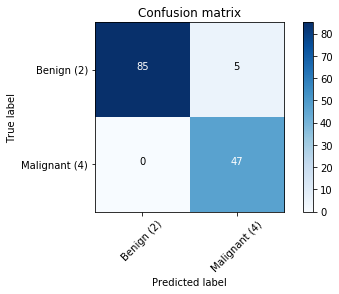

In [13]:
# Compute the confusion matrix

cnf_matrix = confusion_matrix(y_test, yhat, labels = [2,4])
np.set_printoptions(precision = 2)

print(classification_report(y_test, yhat))

plt.figure()
plot_confusion_matrix(cnf_matrix, classes = ['Benign (2)', 'Malignant (4)'], normalize = False, title = 'Confusion matrix')

In [14]:
# Also look at the F1 score and Jacard similarity index

from sklearn.metrics import f1_score
from sklearn.metrics import jaccard_similarity_score

print("Average F1-score: %.4f" % f1_score(y_test, yhat, average = 'weighted'))
print("Jaccard score: %.4f" % jaccard_similarity_score(y_test, yhat))

Average F1-score: 0.9639
Jaccard score: 0.9635


/opt/anaconda3/lib/python3.7/site-packages/sklearn/metrics/_classification.py:664: FutureWarning: jaccard_similarity_score has been deprecated and replaced with jaccard_score. It will be removed in version 0.23. This implementation has surprising behavior for binary and multiclass classification tasks.
  FutureWarning)


## Repeating the example with linear kernelling

              precision    recall  f1-score   support

           2       1.00      0.94      0.97        90
           4       0.90      1.00      0.95        47

    accuracy                           0.96       137
   macro avg       0.95      0.97      0.96       137
weighted avg       0.97      0.96      0.96       137

Confusion matrix, without normalization
[[85  5]
 [ 0 47]]
Average F1-score: 0.9639
Jaccard score: 0.9635


/opt/anaconda3/lib/python3.7/site-packages/sklearn/metrics/_classification.py:664: FutureWarning: jaccard_similarity_score has been deprecated and replaced with jaccard_score. It will be removed in version 0.23. This implementation has surprising behavior for binary and multiclass classification tasks.
  FutureWarning)


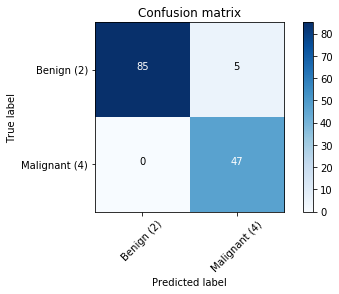

In [15]:
clf = svm.SVC(kernel = 'linear')
clf.fit(X_train, y_train)
yhat2 = clf.predict(X_test)

cnf_matrix = confusion_matrix(y_test, yhat2, labels = [2,4])
np.set_printoptions(precision = 2)

print(classification_report(y_test, yhat2))

plt.figure()
plot_confusion_matrix(cnf_matrix, classes = ['Benign (2)', 'Malignant (4)'], normalize = False, title = 'Confusion matrix')

print("Average F1-score: %.4f" % f1_score(y_test, yhat2, average = 'weighted'))
print("Jaccard score: %.4f" % jaccard_similarity_score(y_test, yhat2))